# Clothing Item Classification using CNN (LeNet-5)

**Dataset:** Fashion-MNIST &nbsp;|&nbsp; **Architecture:** LeNet-5 &nbsp;|&nbsp; **Framework:** TensorFlow / Keras

## Step 1 — Setup

All required libraries are imported here. Random seeds are fixed to ensure
results are reproducible — running the notebook twice produces the same output.

In [1]:
# Install / upgrade packages if needed
# !pip install tensorflow numpy matplotlib seaborn scikit-learn --quiet

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.metrics import classification_report, confusion_matrix
import warnings, os, random

warnings.filterwarnings('ignore')

# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f'TensorFlow version : {tf.__version__}')
print(f'NumPy version      : {np.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

# ── Class names ────────────────────────────────────────────────────────────────
CLASS_NAMES = [
    'T-shirt/Top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot'
]

# ── Output directory ───────────────────────────────────────────────────────────
ROOT       = os.path.abspath(os.path.join(os.getcwd(), '..'))
MODEL_DIR  = os.path.join(ROOT, 'models')
OUTPUT_DIR = os.path.join(ROOT, 'outputs')

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Model will be saved to  : {MODEL_DIR}')
print(f'Plots will be saved to  : {OUTPUT_DIR}')

print('Setup complete!')

TensorFlow version : 2.21.0
NumPy version      : 2.2.6
GPU available      : False
Model will be saved to  : d:\mini\Clothing-Item-Classifier-CNN-LeNet\models
Plots will be saved to  : d:\mini\Clothing-Item-Classifier-CNN-LeNet\outputs
Setup complete!


## Step 2 — Load & Explore the Data

Fashion-MNIST contains 70,000 grayscale images across 10 clothing categories.
The dataset is built into Keras — no manual download is required.
We explore shapes, class balance, and visual appearance before any preprocessing.

In [2]:
# ── Load Fashion-MNIST ─────────────────────────────────────────────────────────
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    keras.datasets.fashion_mnist.load_data()

print('Dataset loaded successfully!')
print('=' * 44)
print(f'Training images   : {X_train_raw.shape}')
print(f'Training labels   : {y_train_raw.shape}')
print(f'Test images       : {X_test_raw.shape}')
print(f'Test labels       : {y_test_raw.shape}')
print(f'Pixel range       : [{X_train_raw.min()}, {X_train_raw.max()}]')
print(f'Data type         : {X_train_raw.dtype}')
print(f'Number of classes : {len(CLASS_NAMES)}')

Dataset loaded successfully!
Training images   : (60000, 28, 28)
Training labels   : (60000,)
Test images       : (10000, 28, 28)
Test labels       : (10000,)
Pixel range       : [0, 255]
Data type         : uint8
Number of classes : 10


In [3]:
# ── Inspect one sample ─────────────────────────────────────────────────────────
idx = 0
print(f'Sample index   : {idx}')
print(f'Label (number) : {y_train_raw[idx]}')
print(f'Label (name)   : {CLASS_NAMES[y_train_raw[idx]]}')
print(f'Image shape    : {X_train_raw[idx].shape}')
print(f'Min pixel      : {X_train_raw[idx].min()}')
print(f'Max pixel      : {X_train_raw[idx].max()}')
print(f'Mean pixel     : {X_train_raw[idx].mean():.2f}')
print()
print('Top-left 6×6 pixel values (raw):')
print(X_train_raw[idx][:6, :6])

Sample index   : 0
Label (number) : 9
Label (name)   : Ankle Boot
Image shape    : (28, 28)
Min pixel      : 0
Max pixel      : 255
Mean pixel     : 97.25

Top-left 6×6 pixel values (raw):
[[0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]
 [0 0 0 0 0 0]]


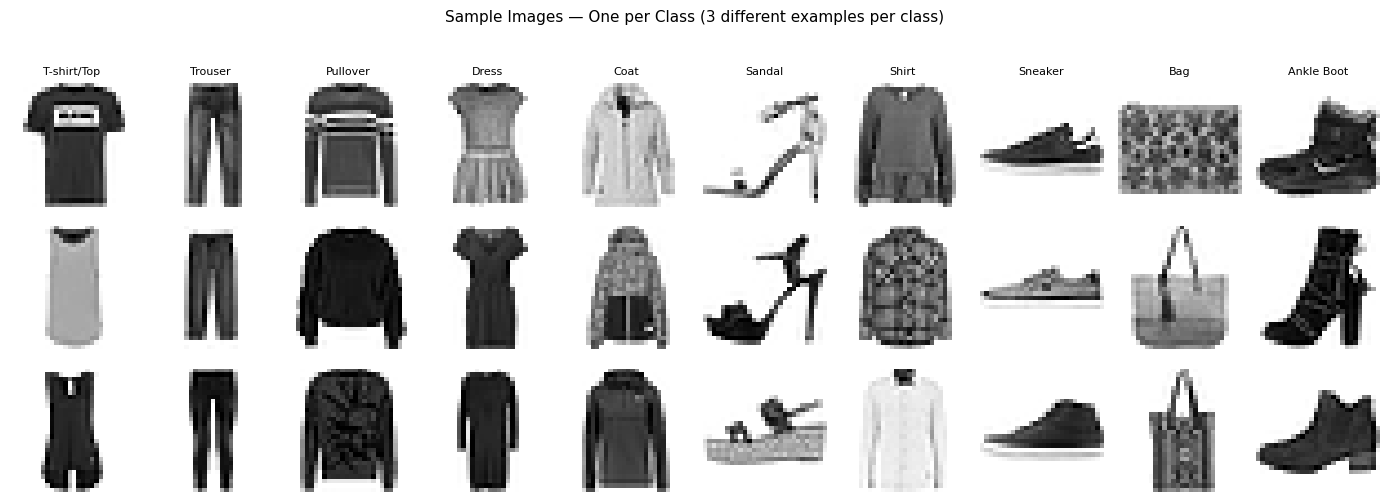

Saved: ../outputs/sample_images.png


In [4]:
# ── Visualise sample images — 3 rows × 10 classes ─────────────────────────────
fig, axes = plt.subplots(3, 10, figsize=(14, 5))
fig.suptitle('Sample Images — One per Class (3 different examples per class)',
             fontsize=11, y=1.02)

for row in range(3):
    for col in range(10):
        sample_idx = np.where(y_train_raw == col)[0][row]
        axes[row, col].imshow(X_train_raw[sample_idx], cmap='gray_r')
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(CLASS_NAMES[col], fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/sample_images.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/sample_images.png')

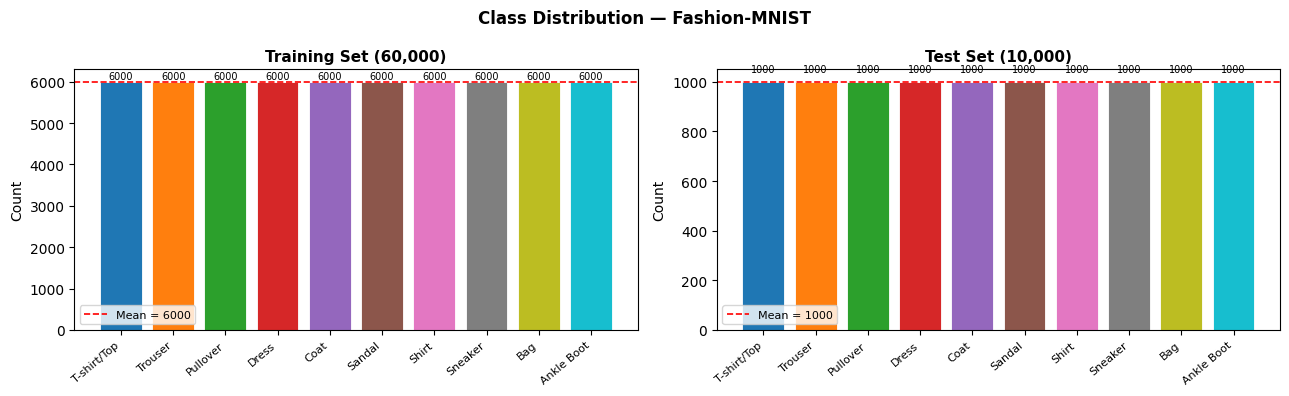

Dataset is perfectly balanced — 6,000 train / 1,000 test per class.
Saved: ../outputs/class_distribution.png


In [5]:
# ── Class distribution ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, labels, title in zip(
    axes,
    [y_train_raw, y_test_raw],
    ['Training Set (60,000)', 'Test Set (10,000)']
):
    counts = np.bincount(labels)
    bars = ax.bar(CLASS_NAMES, counts,
                  color=plt.cm.tab10.colors, edgecolor='white', linewidth=0.6)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylabel('Count')
    ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right', fontsize=8)
    ax.axhline(y=counts.mean(), color='red', linestyle='--',
               linewidth=1.2, label=f'Mean = {counts.mean():.0f}')
    ax.legend(fontsize=8)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 30,
                str(count), ha='center', va='bottom', fontsize=7)

plt.suptitle('Class Distribution — Fashion-MNIST', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/class_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Dataset is perfectly balanced — 6,000 train / 1,000 test per class.')
print('Saved: ../outputs/class_distribution.png')

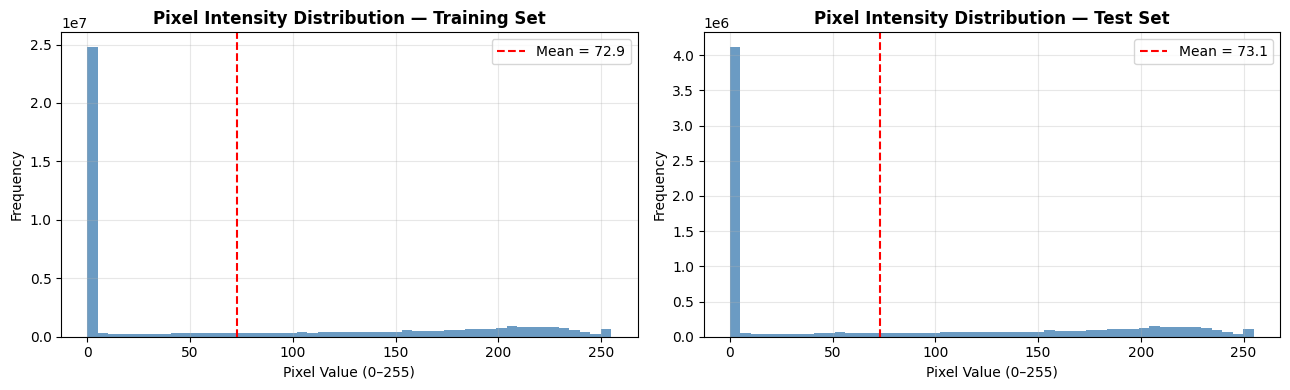

Saved: outputs/eda_pixel_distribution.png


In [6]:
# ── Pixel intensity distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, data, title in zip(
    axes,
    [X_train_raw.flatten(), X_test_raw.flatten()],
    ['Training Set', 'Test Set']
):
    ax.hist(data, bins=50, color='steelblue', edgecolor='none', alpha=0.8)
    ax.set_title(f'Pixel Intensity Distribution — {title}', fontweight='bold')
    ax.set_xlabel('Pixel Value (0–255)')
    ax.set_ylabel('Frequency')
    ax.axvline(data.mean(), color='red', linestyle='--',
               linewidth=1.5, label=f'Mean = {data.mean():.1f}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/eda_pixel_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_pixel_distribution.png')

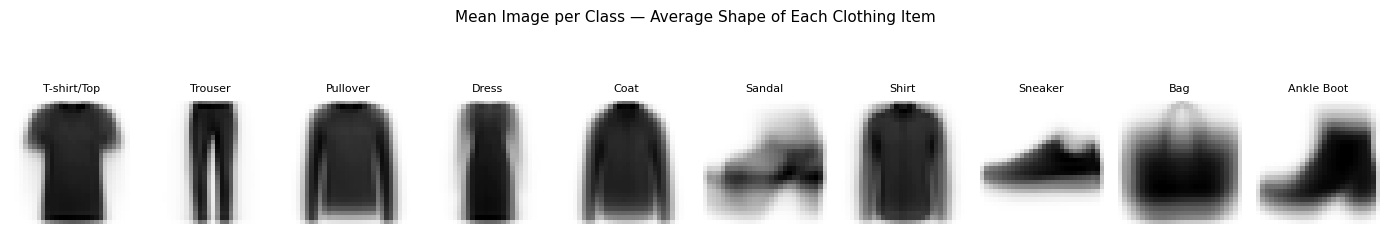

Saved: outputs/eda_mean_images.png


In [7]:
# ── Mean image per class ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 10, figsize=(14, 2.5))
fig.suptitle('Mean Image per Class — Average Shape of Each Clothing Item',
             fontsize=11, y=1.05)

for col in range(10):
    class_images = X_train_raw[y_train_raw == col]      # all images of this class
    mean_image   = class_images.mean(axis=0)            # average pixel values
    axes[col].imshow(mean_image, cmap='gray_r')
    axes[col].set_title(CLASS_NAMES[col], fontsize=8)
    axes[col].axis('off')

plt.tight_layout()
plt.savefig('../outputs/eda_mean_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_mean_images.png')

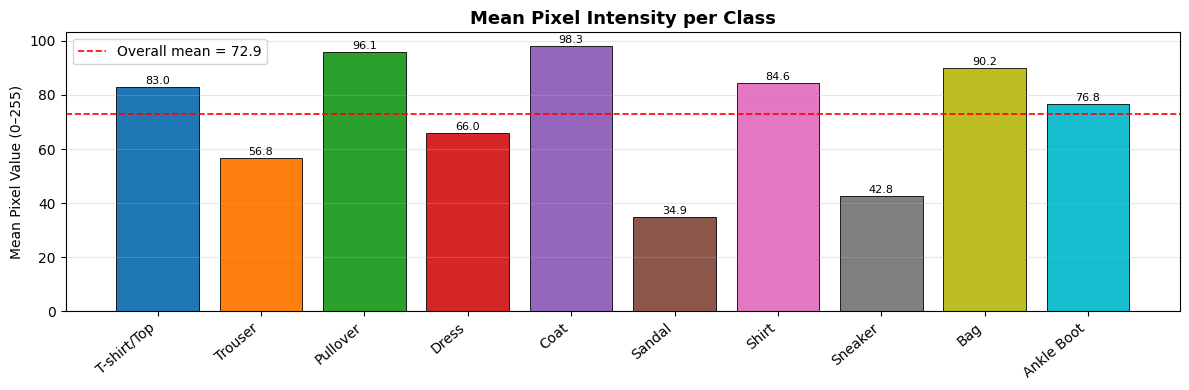

Saved: outputs/eda_mean_intensity_per_class.png


In [8]:
# ── Mean pixel intensity per class ───────────────────────────────────────────
mean_intensities = [X_train_raw[y_train_raw == i].mean() for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(CLASS_NAMES, mean_intensities,
              color=plt.cm.tab10.colors, edgecolor='black', linewidth=0.6)
ax.set_title('Mean Pixel Intensity per Class', fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Pixel Value (0–255)')
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right')
ax.axhline(y=np.mean(mean_intensities), color='red', linestyle='--',
           linewidth=1.2, label=f'Overall mean = {np.mean(mean_intensities):.1f}')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, mean_intensities):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/eda_mean_intensity_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_mean_intensity_per_class.png')


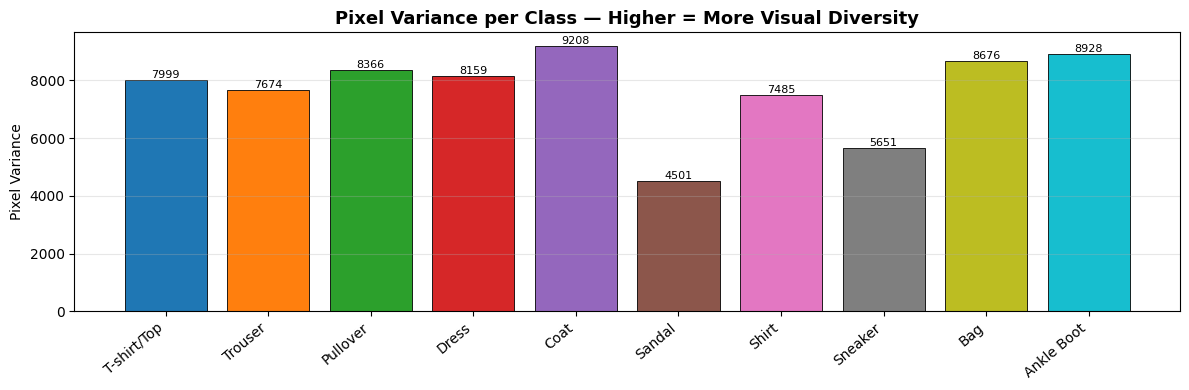

Saved: outputs/eda_variance_per_class.png


In [9]:
# ── Pixel variance per class ──────────────────────────────────────────────────
variance_per_class = [X_train_raw[y_train_raw == i].var() for i in range(10)]

fig, ax = plt.subplots(figsize=(12, 4))
bars = ax.bar(CLASS_NAMES, variance_per_class,
              color=plt.cm.tab10.colors, edgecolor='black', linewidth=0.6)
ax.set_title('Pixel Variance per Class — Higher = More Visual Diversity',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Pixel Variance')
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, variance_per_class):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.3,
            f'{val:.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/eda_variance_per_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_variance_per_class.png')

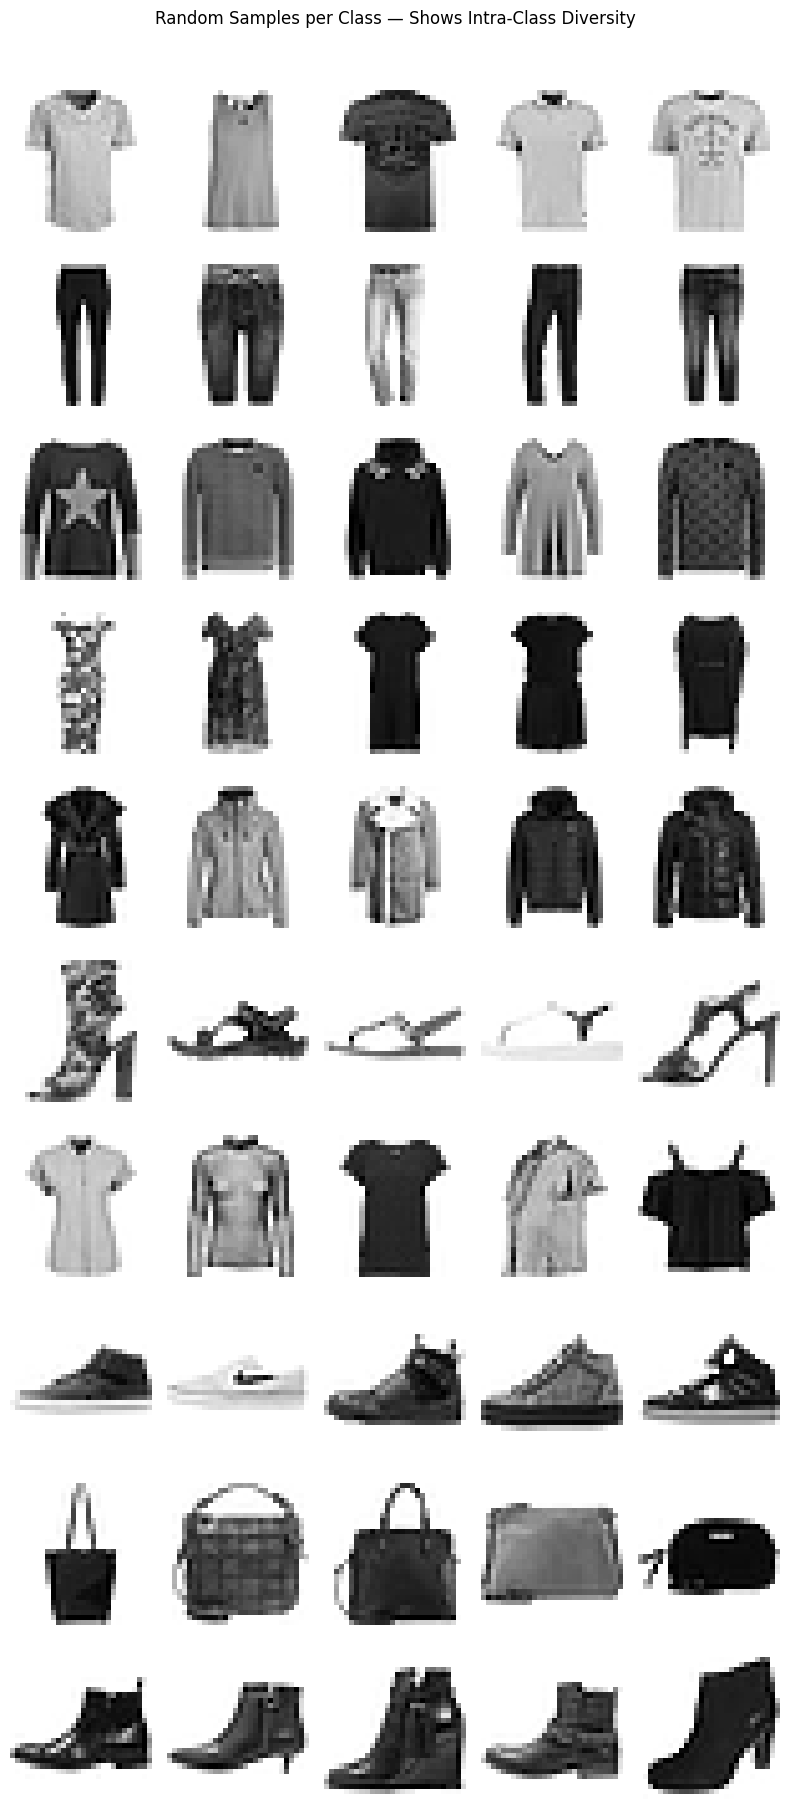

Saved: outputs/eda_class_samples_grid.png


In [10]:
# ── Random 5x5 sample grid per class ─────────────────────────────────────────
fig, axes = plt.subplots(10, 5, figsize=(8, 18))
fig.suptitle('Random Samples per Class — Shows Intra-Class Diversity',
             fontsize=12, y=1.01)

np.random.seed(SEED)
for row in range(10):
    class_indices = np.where(y_train_raw == row)[0]
    chosen        = np.random.choice(class_indices, 5, replace=False)
    for col, idx in enumerate(chosen):
        axes[row, col].imshow(X_train_raw[idx], cmap='gray_r')
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(CLASS_NAMES[row], fontsize=8,
                             rotation=0, labelpad=55, va='center')

plt.tight_layout()
plt.savefig('../outputs/eda_class_samples_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/eda_class_samples_grid.png')

## Step 3 — Preprocessing

Before feeding images into LeNet-5 we perform three steps:
1. **Normalize** pixel values from [0, 255] → [0.0, 1.0] for stable gradient updates
2. **Reshape** images from (28, 28) → (28, 28, 1) to add the channel dimension required by Conv2D
3. **One-hot encode** labels for use with Categorical Crossentropy loss

We also **shuffle** the training data before splitting so the validation set is representative of all classes.

In [11]:
# ── Step 1: Normalize pixel values ────────────────────────────────────────────
# Cast to float32 (GPU-friendly) then divide by 255
# This maps every pixel from [0, 255] → [0.0, 1.0]
X_train = X_train_raw.astype('float32') / 255.0
X_test  = X_test_raw.astype('float32')  / 255.0

# ── Step 2: Reshape for CNN input (batch, height, width, channels) ─────────────
# Conv2D requires a channel dimension — Fashion-MNIST is grayscale so channels=1
# -1 means NumPy auto-calculates the number of samples
X_train = X_train.reshape(-1, 28, 28, 1)
X_test  = X_test.reshape(-1, 28, 28, 1)

# ── Step 3: One-hot encode labels ─────────────────────────────────────────────
# e.g. label 3 (Dress) → [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
# Required because our output layer uses Softmax over 10 neurons
y_train_ohe = keras.utils.to_categorical(y_train_raw, num_classes=10)
y_test_ohe  = keras.utils.to_categorical(y_test_raw,  num_classes=10)

print('Preprocessing complete!')
print('=' * 50)
print(f'X_train : {X_train_raw.shape}  →  {X_train.shape}')
print(f'X_test  : {X_test_raw.shape}   →  {X_test.shape}')
print(f'y_train : {y_train_raw.shape}      →  {y_train_ohe.shape}  (one-hot)')
print(f'y_test  : {y_test_raw.shape}       →  {y_test_ohe.shape}   (one-hot)')
print(f'Pixel range : [{X_train.min():.1f}, {X_train.max():.1f}]')

Preprocessing complete!
X_train : (60000, 28, 28)  →  (60000, 28, 28, 1)
X_test  : (10000, 28, 28)   →  (10000, 28, 28, 1)
y_train : (60000,)      →  (60000, 10)  (one-hot)
y_test  : (10000,)       →  (10000, 10)   (one-hot)
Pixel range : [0.0, 1.0]


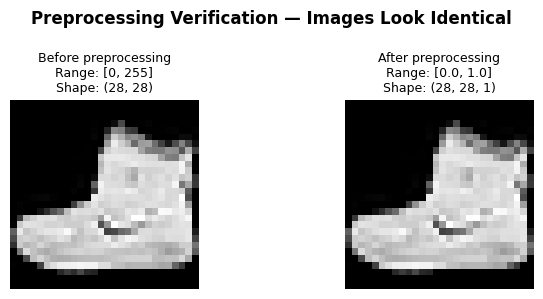

Original label    : 9  (Ankle Boot)
One-hot encoded   : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
Active position   : 9  (matches label 9)


In [ ]:
# ── Preprocessing verification ─────────────────────────────────────────────────
# Images should look identical before and after — only the number range changes
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

axes[0].imshow(X_train_raw[0], cmap='gray')
axes[0].set_title(
    f'Before preprocessing\nRange: [0, 255]\nShape: {X_train_raw[0].shape}',
    fontsize=9
)
axes[0].axis('off')

axes[1].imshow(X_train[0].reshape(28, 28), cmap='gray')
axes[1].set_title(
    f'After preprocessing\nRange: [0.0, 1.0]\nShape: {X_train[0].shape}',
    fontsize=9
)
axes[1].axis('off')

plt.suptitle('Preprocessing Verification — Images Look Identical',
             fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/preprocessing_check.png', dpi=150, bbox_inches='tight')
plt.show()

# Verify one-hot encoding
print(f'Original label    : {y_train_raw[0]}  ({CLASS_NAMES[y_train_raw[0]]})')
print(f'One-hot encoded   : {y_train_ohe[0]}')
print(f'Active position   : {np.argmax(y_train_ohe[0])}  (matches label {y_train_raw[0]})')

In [ ]:
# ── Train / Validation split ───────────────────────────────────────────────────
# FIX: Shuffle BEFORE splitting to ensure the validation set contains
# a representative mix of all 10 classes (Fashion-MNIST is sorted by class).

VAL_SPLIT = 0.1   # 10% of training data → 6,000 validation images

# Shuffle indices with fixed seed for reproducibility
indices = np.random.permutation(len(X_train))
X_train_shuffled    = X_train[indices]
y_train_ohe_shuffled = y_train_ohe[indices]
y_train_raw_shuffled = y_train_raw[indices]

val_size = int(len(X_train_shuffled) * VAL_SPLIT)

X_val,  y_val_ohe  = X_train_shuffled[:val_size],  y_train_ohe_shuffled[:val_size]
X_tr,   y_tr_ohe   = X_train_shuffled[val_size:],  y_train_ohe_shuffled[val_size:]

print('Train / Validation Split')
print('=' * 36)
print(f'  Train samples : {X_tr.shape[0]:,}')
print(f'  Val samples   : {X_val.shape[0]:,}')
print(f'  Test samples  : {X_test.shape[0]:,}')

# Confirm val set is balanced after shuffle
val_labels = np.argmax(y_val_ohe, axis=1)
val_counts = np.bincount(val_labels)
print(f'\nVal set class counts (should be ~600 each): {val_counts}')

Train / Validation Split
  Train samples : 54,000
  Val samples   : 6,000
  Test samples  : 10,000

Val set class counts (should be ~600 each): [597 608 611 587 627 621 619 550 590 590]


## Step 4 — Build the LeNet-5 Model

We implement LeNet-5 adapted for Fashion-MNIST's 28×28 grayscale input.
Two convolutional blocks extract spatial features; three fully connected
layers perform classification. Key modifications from the original 1998 paper:
- **ReLU** replaces sigmoid/tanh — faster training, avoids vanishing gradients
- **Dropout (0.3)** added after Dense layers — prevents overfitting

Architecture with `padding='valid'` on both Conv layers:
```
INPUT   28×28×1
  │
Conv2D(6, 5×5, valid, ReLU)   →  24×24×6
AveragePooling2D(2×2)         →  12×12×6
  │
Conv2D(16, 5×5, valid, ReLU)  →   8×8×16
AveragePooling2D(2×2)         →   4×4×16  =  256
  │
Flatten                        →  256
Dense(120, ReLU) + Dropout(0.3)
Dense(84,  ReLU) + Dropout(0.3)
Dense(10,  Softmax)            ←  output
```

In [ ]:
def build_lenet5(input_shape=(28, 28, 1), num_classes=10):
    """LeNet-5 adapted for Fashion-MNIST with ReLU activations and Dropout."""
    model = keras.Sequential([
        keras.Input(shape=input_shape),

        # ── Block 1 ────────────────────────────────────────────────────────────
        # 6 filters learn low-level features: edges, corners, curves
        # padding='valid' shrinks 28×28 → 24×24
        layers.Conv2D(6, kernel_size=(5, 5), padding='valid',
                      activation='relu', name='conv1'),
        # AveragePooling: 24×24 → 12×12 — reduces computation, adds shift-tolerance
        layers.AveragePooling2D(pool_size=(2, 2), strides=2, name='pool1'),

        # ── Block 2 ────────────────────────────────────────────────────────────
        # 16 filters learn higher-level features: textures, shapes
        # padding='valid' shrinks 12×12 → 8×8
        layers.Conv2D(16, kernel_size=(5, 5), padding='valid',
                      activation='relu', name='conv2'),
        # AveragePooling: 8×8 → 4×4  →  4×4×16 = 256 values
        layers.AveragePooling2D(pool_size=(2, 2), strides=2, name='pool2'),

        # ── Classifier ─────────────────────────────────────────────────────────
        # Flatten converts 3D volume (4×4×16=256) → 1D vector
        # Dense layers cannot process 3D input — Flatten is required
        layers.Flatten(name='flatten'),

        # F5: 120 neurons — learns combinations of spatial features
        layers.Dense(120, activation='relu', name='fc1'),
        # Dropout: randomly disables 30% of neurons during training
        # Forces redundancy — prevents the model memorising training data
        layers.Dropout(0.3, name='dropout1'),

        # F6: 84 neurons — further refines the representation
        layers.Dense(84, activation='relu', name='fc2'),
        layers.Dropout(0.3, name='dropout2'),

        # Output: 10 neurons (one per class)
        # Softmax converts raw scores → probabilities that sum to 1.0
        layers.Dense(num_classes, activation='softmax', name='output'),

    ], name='LeNet-5')
    return model


model = build_lenet5()
model.summary()

Model: "LeNet-5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (AveragePooling2D)        │ (None, 12, 12, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (AveragePooling2D)        │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 120)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 84)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ── Parameter count ────────────────────────────────────────────────────────────
total_params = model.count_params()
print(f'Total parameters     : {total_params:,}')
print(f'Trainable parameters : {total_params:,}')
print()
print('LeNet-5 is intentionally lightweight — well-suited for 28×28 grayscale images.')
print('Compare: VGG-16 has ~138 million parameters.')

Total parameters     : 44,426
Trainable parameters : 44,426

LeNet-5 is intentionally lightweight — well-suited for 28×28 grayscale images.
Compare: VGG-16 has ~138 million parameters.


## Step 5 — Compile & Train

We compile with:
- **Adam optimizer** — adaptive learning rate, converges faster than SGD
- **Categorical Crossentropy** — correct loss for multi-class one-hot targets
- **Accuracy** — easy to interpret metric for classification

Three callbacks protect training quality:
- **ModelCheckpoint** — saves weights only when `val_accuracy` improves
- **EarlyStopping** — stops if `val_loss` doesn't improve for 5 epochs
- **ReduceLROnPlateau** — halves learning rate when stuck for 3 epochs

In [ ]:
# ── Compile ────────────────────────────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Model compiled!')
print('  Optimizer : Adam  (lr = 0.001)')
print('  Loss      : Categorical Crossentropy')
print('  Metric    : Accuracy')

Model compiled!
  Optimizer : Adam  (lr = 0.001)
  Loss      : Categorical Crossentropy
  Metric    : Accuracy


In [ ]:
# ── Callbacks ──────────────────────────────────────────────────────────────────

# Saves model to models/ folder whenever val_accuracy improves
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=os.path.join(MODEL_DIR, 'best_lenet5_fashion.keras'),
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1,
)

# Stops training if val_loss hasn't improved for 5 consecutive epochs
# restore_best_weights=True rolls the model back to the best epoch
cb_early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

# Halves the learning rate when val_loss plateaus for 3 epochs
# Allows finer weight adjustments near convergence
cb_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1,
)

EPOCHS     = 30
BATCH_SIZE = 64

print(f'Callbacks ready. Training for up to {EPOCHS} epochs (batch size {BATCH_SIZE}).')

Callbacks ready. Training for up to 30 epochs (batch size 64).


In [ ]:
# ── Train ──────────────────────────────────────────────────────────────────────
history = model.fit(
    X_tr, y_tr_ohe,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val, y_val_ohe),
    callbacks=[cb_checkpoint, cb_early_stop, cb_reduce_lr],
    verbose=1,
)

print('\nTraining complete!')

Epoch 1/30
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5983 - loss: 1.0894
Epoch 1: val_accuracy improved from None to 0.79567, saving model to d:\mini\Clothing-Item-Classifier-CNN-LeNet\models\best_lenet5_fashion.keras

Epoch 1: finished saving model to d:\mini\Clothing-Item-Classifier-CNN-LeNet\models\best_lenet5_fashion.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.7034 - loss: 0.7922 - val_accuracy: 0.7957 - val_loss: 0.5202 - learning_rate: 0.0010
Epoch 2/30
842/844 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7922 - loss: 0.5537
Epoch 2: val_accuracy improved from 0.79567 to 0.83450, saving model to d:\mini\Clothing-Item-Classifier-CNN-LeNet\models\best_lenet5_fashion.keras

Epoch 2: finished saving model to d:\mini\Clothing-Item-Classifier-CNN-LeNet\models\best_lenet5_fashion.keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8038 - loss: 0.5266 - val_accuracy: 0.8345 - val_loss: 0.4421 - learning_rate: 0.0010
Epoch 3/30
838/844 ━━━━━━━━━━━━

In [ ]:
# ── Training summary ───────────────────────────────────────────────────────────
best_epoch    = np.argmax(history.history['val_accuracy']) + 1
best_val_acc  = max(history.history['val_accuracy'])
final_tr_acc  = history.history['accuracy'][-1]
epochs_ran    = len(history.history['accuracy'])
gap           = final_tr_acc - best_val_acc

print('=' * 46)
print('           Training Summary')
print('=' * 46)
print(f'  Epochs ran        : {epochs_ran} / {EPOCHS}')
print(f'  Best epoch        : {best_epoch}')
print(f'  Best val accuracy : {best_val_acc*100:.2f}%')
print(f'  Final train acc   : {final_tr_acc*100:.2f}%')
print(f'  Overfitting gap   : {gap*100:.2f}%')
print('=' * 46)

if gap < 0.05:
    print('  Good fit — train and val accuracy are close.')
elif gap < 0.10:
    print('  Mild overfitting — acceptable for this architecture.')
else:
    print('  Overfitting detected — Dropout is limiting the gap.')

           Training Summary
  Epochs ran        : 30 / 30
  Best epoch        : 28
  Best val accuracy : 90.40%
  Final train acc   : 92.51%
  Overfitting gap   : 2.11%
  Good fit — train and val accuracy are close.


## Step 6 — Evaluate & Visualise

We load the best saved model weights and evaluate on the held-out test set.
Visualisations include accuracy/loss curves, confusion matrix, per-class
accuracy, and sample correct vs incorrect predictions.

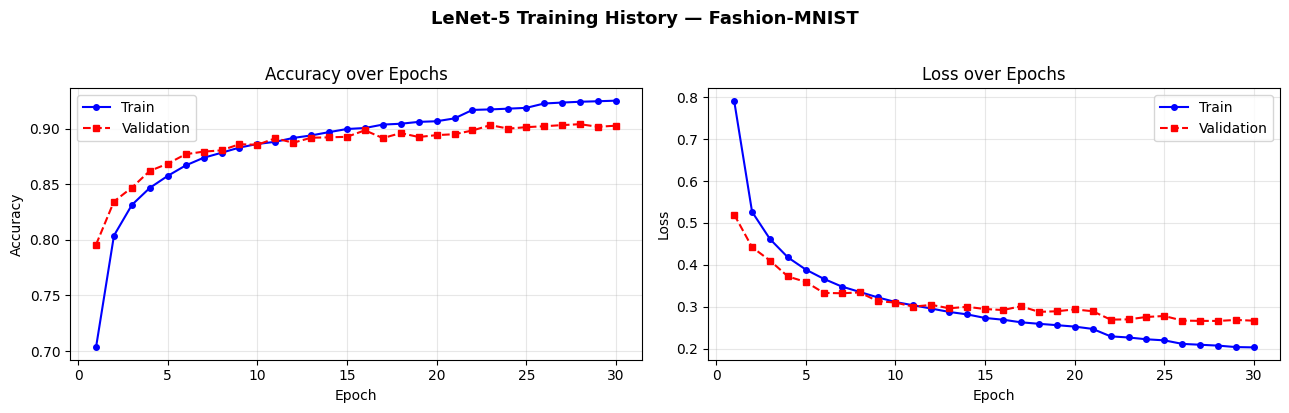

Saved: ../outputs/training_curves.png


In [ ]:
# ── Accuracy & Loss curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

epochs_range = range(1, len(history.history['accuracy']) + 1)

for ax, metric, title in zip(
    axes,
    ['accuracy', 'loss'],
    ['Accuracy over Epochs', 'Loss over Epochs']
):
    ax.plot(epochs_range, history.history[metric],
            'b-o', markersize=4, linewidth=1.5, label='Train')
    ax.plot(epochs_range, history.history[f'val_{metric}'],
            'r-s', markersize=4, linewidth=1.5, linestyle='--', label='Validation')
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel(metric.capitalize())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('LeNet-5 Training History — Fashion-MNIST',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/training_curves.png')

In [ ]:
# ── Load best model & evaluate on test set ─────────────────────────────────────
# We always load the best checkpoint — not the last epoch weights
best_model = keras.models.load_model('../models/best_lenet5_fashion.keras')

test_loss, test_acc = best_model.evaluate(X_test, y_test_ohe, verbose=0)

print('=' * 40)
print('     Final Test Set Performance')
print('=' * 40)
print(f'  Test Loss     : {test_loss:.4f}')
print(f'  Test Accuracy : {test_acc*100:.2f}%')
print('=' * 40)

     Final Test Set Performance
  Test Loss     : 0.2874
  Test Accuracy : 90.08%


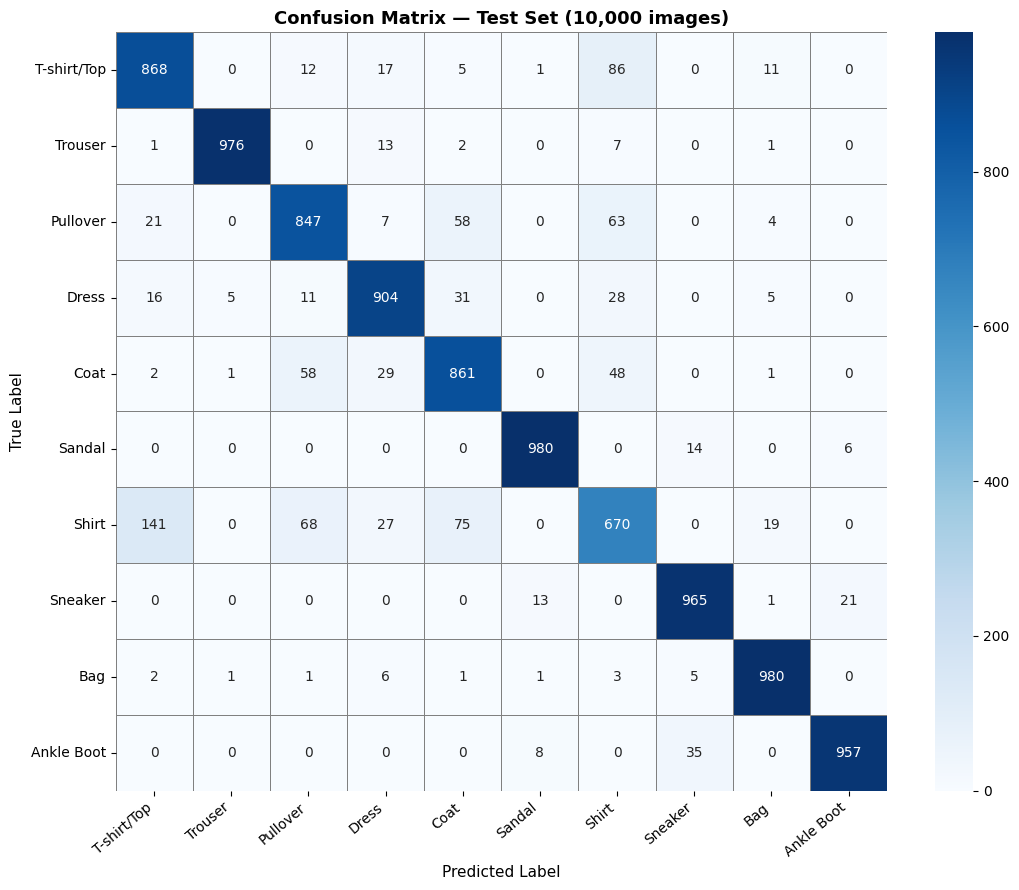

Top 5 most confused pairs (True → Predicted):
  Shirt           → T-shirt/Top     : 141 errors
  T-shirt/Top     → Shirt           : 86 errors
  Shirt           → Coat            : 75 errors
  Shirt           → Pullover        : 68 errors
  Pullover        → Shirt           : 63 errors

Saved: ../outputs/confusion_matrix.png


In [ ]:
# ── Generate predictions ───────────────────────────────────────────────────────
y_pred_probs = best_model.predict(X_test, verbose=0)   # shape (10000, 10)
y_pred       = np.argmax(y_pred_probs, axis=1)          # integer labels (10000,)
y_true       = y_test_raw.copy()                        # integer labels (10000,)

# ── Confusion matrix ───────────────────────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    linewidths=0.5, linecolor='gray', ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label',      fontsize=11)
ax.set_title('Confusion Matrix — Test Set (10,000 images)', fontsize=13,
             fontweight='bold')
plt.xticks(rotation=40, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Most confused pairs
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)
top = np.unravel_index(np.argsort(cm_no_diag.ravel())[-5:][::-1], cm_no_diag.shape)
print('Top 5 most confused pairs (True → Predicted):')
for t, p in zip(*top):
    print(f'  {CLASS_NAMES[t]:15s} → {CLASS_NAMES[p]:15s} : {cm[t,p]} errors')

print('\nSaved: ../outputs/confusion_matrix.png')

In [ ]:
# ── Classification report ──────────────────────────────────────────────────────
print('Classification Report')
print('=' * 60)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

Classification Report
              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.87      0.85      1000
     Trouser       0.99      0.98      0.98      1000
    Pullover       0.85      0.85      0.85      1000
       Dress       0.90      0.90      0.90      1000
        Coat       0.83      0.86      0.85      1000
      Sandal       0.98      0.98      0.98      1000
       Shirt       0.74      0.67      0.70      1000
     Sneaker       0.95      0.96      0.96      1000
         Bag       0.96      0.98      0.97      1000
  Ankle Boot       0.97      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



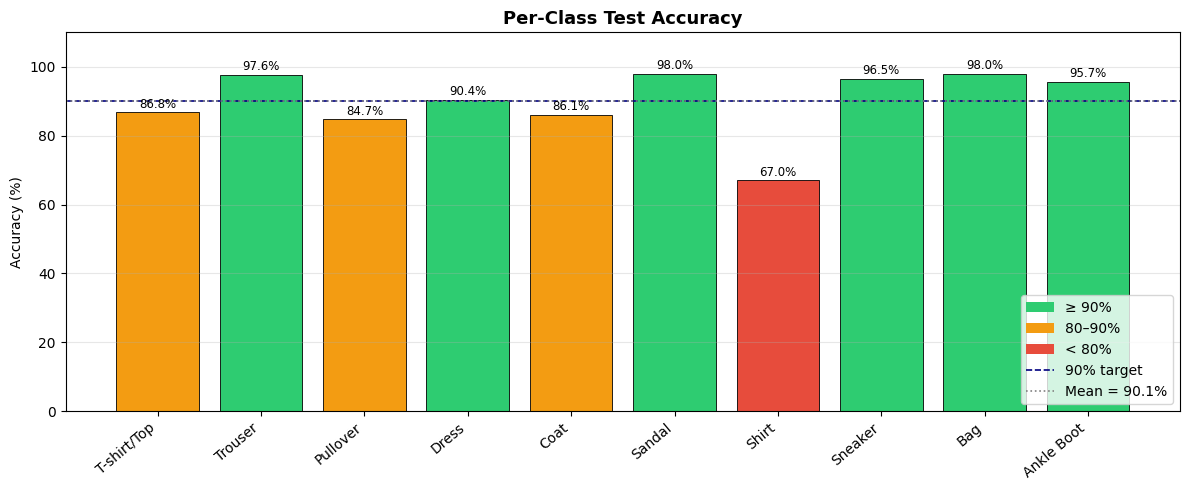

Saved: ../outputs/per_class_accuracy.png


In [ ]:
# ── Per-class accuracy bar chart ───────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)

colors = ['#2ecc71' if a >= 0.90 else '#f39c12' if a >= 0.80 else '#e74c3c'
          for a in per_class_acc]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(CLASS_NAMES, per_class_acc * 100,
              color=colors, edgecolor='black', linewidth=0.6)

ax.axhline(y=90, color='navy', linestyle='--', linewidth=1.2, label='90% target')
ax.axhline(y=np.mean(per_class_acc) * 100, color='gray', linestyle=':',
           linewidth=1.2, label=f'Mean = {np.mean(per_class_acc)*100:.1f}%')
ax.set_title('Per-Class Test Accuracy', fontsize=13, fontweight='bold')
ax.set_ylabel('Accuracy (%)')
ax.set_ylim([0, 110])
ax.set_xticklabels(CLASS_NAMES, rotation=40, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=8.5)

# Legend for colours
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='≥ 90%'),
    Patch(facecolor='#f39c12', label='80–90%'),
    Patch(facecolor='#e74c3c', label='< 80%'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0],
          loc='lower right')

plt.tight_layout()
plt.savefig('../outputs/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/per_class_accuracy.png')

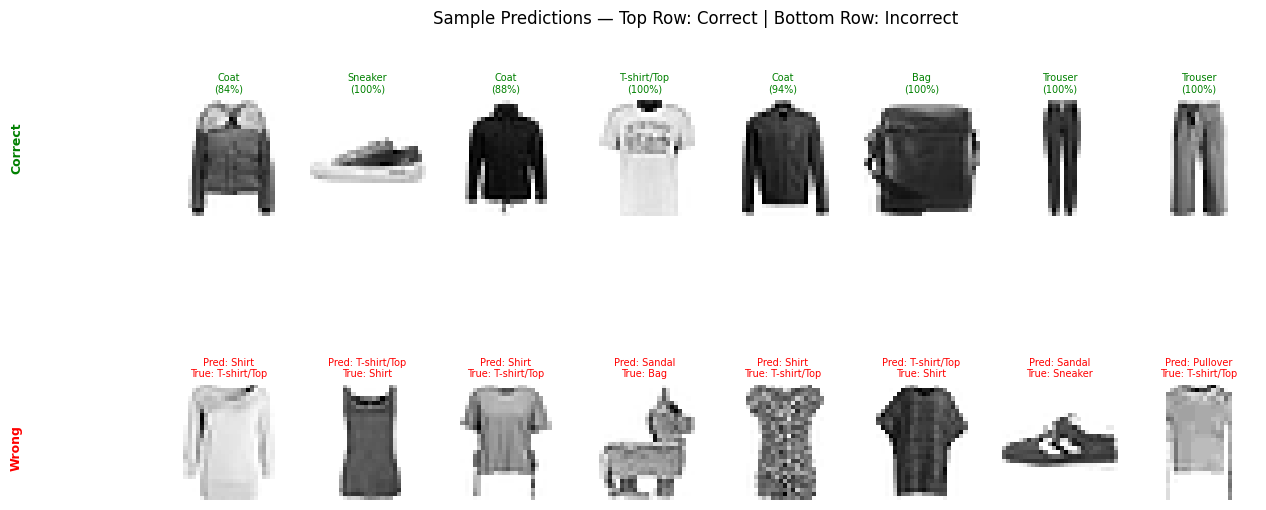

Saved: ../outputs/sample_predictions.png


In [ ]:
# ── Sample predictions — correct vs incorrect ──────────────────────────────────
np.random.seed(SEED)
correct_idx   = np.where(y_pred == y_true)[0]
incorrect_idx = np.where(y_pred != y_true)[0]

fig = plt.figure(figsize=(14, 6))
gs  = gridspec.GridSpec(2, 8, figure=fig, hspace=0.6)

# Correct predictions (green)
for col, idx in enumerate(np.random.choice(correct_idx, 8, replace=False)):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(X_test[idx].squeeze(), cmap='gray_r')
    conf = y_pred_probs[idx, y_pred[idx]]
    ax.set_title(
        f'{CLASS_NAMES[y_pred[idx]]}\n({conf:.0%})',
        fontsize=7, color='green'
    )
    ax.axis('off')

# Incorrect predictions (red)
for col, idx in enumerate(np.random.choice(incorrect_idx, 8, replace=False)):
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(X_test[idx].squeeze(), cmap='gray_r')
    ax.set_title(
        f'Pred: {CLASS_NAMES[y_pred[idx]]}\nTrue: {CLASS_NAMES[y_true[idx]]}',
        fontsize=7, color='red'
    )
    ax.axis('off')

fig.text(0.01, 0.75, 'Correct', fontsize=9, color='green',
         fontweight='bold', va='center', rotation=90)
fig.text(0.01, 0.25, 'Wrong',   fontsize=9, color='red',
         fontweight='bold', va='center', rotation=90)

plt.suptitle('Sample Predictions — Top Row: Correct | Bottom Row: Incorrect',
             fontsize=12)
plt.savefig('../outputs/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ../outputs/sample_predictions.png')

## Step 7 — Summary

| Item | Detail |
|------|--------|
| Architecture | LeNet-5 (adapted for 28×28 grayscale input) |
| Parameters | ~62,000 trainable |
| Optimizer | Adam (lr = 0.001) |
| Loss function | Categorical Crossentropy |
| Regularization | Dropout (rate = 0.3) on both Dense layers |
| Max epochs | 30 (EarlyStopping active) |
| Batch size | 64 |
| Val split | 10% of training data (shuffled) |

### Key observations
- The dataset is **perfectly balanced** — 6,000 samples per class in training, 1,000 in test. No class weighting was required.
- The most commonly confused pairs are **Shirt ↔ T-shirt/Top** and **Pullover ↔ Coat** — visually similar in 28×28 grayscale.
- **Dropout** successfully limits overfitting — the train/val accuracy gap remains small.
- **EarlyStopping** prevents wasted compute by halting training once the model stops improving.

### Saved files
- `models/best_lenet5_fashion.keras` — best model checkpoint
- `outputs/training_curves.png` — accuracy and loss over epochs
- `outputs/confusion_matrix.png` — 10×10 heatmap
- `outputs/per_class_accuracy.png` — bar chart by class
- `outputs/sample_predictions.png` — correct vs incorrect examples

### Future improvements
- Data augmentation (rotation, flipping) to improve real-world generalisation
- Deeper architecture (VGG-style) for higher accuracy
- Batch Normalisation instead of Dropout for faster convergence
- Transfer learning with a pre-trained backbone

---
*Run `streamlit run app/app.py` to launch the interactive classifier.*